# 🚨 [DCC Mission 2] 119 긴급 신고 전화 화자 분류 (Speaker Classification)
### 🏆 2026 데이터+AI 혁신 챌린지 (대학부 예선)

* **과제 정의**: 119 신고 통화 음성 조각(`.wav`)을 분석하여 발화자가 **신고자(Caller = 1)**인지 **119 대원(Agent = 0)**인지 분류
* **엄격한 제약 사항 (규칙 위반 시 실격)**:
  1. `startAt`, `endAt` 이외의 **텍스트(전사 내용) annotation 사용 절대 불가** (오직 오디오 물리적 특징만 사용)
  2. 통화 발화의 순서(첫 발화 대원, 두 번째 신고자 등 홀짝 순서) 정보 활용 불가
* **멘토 핵심 피드백 (본 노트북 반영 완료)**:
  - *"단순히 모델만 바꾸지 말고, 전처리(윈도우 길이, 패딩, STFT 파라미터 등) 기준에 대한 **Ablation Study(비교 실험)**을 직접 수행하고 일지/표로 근거를 남길 것."*
* **환경 안내**: 로컬 VS Code에서 Google Colab Pro GPU(A100/V100) 런타임에 연결하여 원격으로 실행하도록 최적화되어 있습니다.


---
## 📦 1. 환경 준비 & 구글 드라이브 분할 압축 고속 해제

> ⚠️ **구글 드라이브 FUSE I/O 병목 방지 필수 조치**:
> 구글 드라이브(`/content/drive`)에서 수만 개의 작은 `.wav` 파일을 직접 열고 닫으면 FUSE 계층 병목으로 학습이 30배 이상 느려집니다.
> 아래 코드는 드라이브에 보관된 분할 압축 파일(`data-001.zip` ~ `data-013.zip`)을 **Colab 로컬 초고속 NVMe SSD(`/content/data`)**로 단 1~2분 만에 일괄 해제합니다.


In [8]:
# [1] GPU 확인 및 필수 도구(7zip) 설치
import subprocess, sys, os

try:
    import torch
    print(f"🚀 PyTorch 버전: {torch.__version__}")
    print(f"🎮 CUDA 사용 가능 여부: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"🔥 할당된 GPU: {torch.cuda.get_device_name(0)}")
except Exception as e:
    print(f"GPU 확인 오류: {e}")

# Colab 환경 여부 확인
IS_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IS_COLAB:
    print("🌐 Google Colab 환경이 감지되었습니다.")
    # p7zip 설치 (초고속 멀티스레드 압축 해제)
    subprocess.run(["apt-get", "install", "p7zip-full", "-y"], stdout=subprocess.DEVNULL)
    
    # 구글 드라이브 마운트 확인 및 처리
    drive_mounted = os.path.exists('/content/drive/MyDrive')
    if drive_mounted:
        print("✅ 구글 드라이브가 이미 정상적으로 마운트되어 있습니다!")
    else:
        print("🔄 구글 드라이브 마운트를 시도합니다...")
        try:
            from google.colab import drive
            drive.mount('/content/drive')
            drive_mounted = os.path.exists('/content/drive/MyDrive')
        except Exception as e:
            print("⚠️ [VS Code ↔ Colab 인증 알림]")
            print("   VS Code 원격 연결 환경에서는 보안상 브라우저 승인 팝업이 직접 뜨지 않아 drive.mount() 오류(Error 400)가 발생할 수 있습니다.")
            print("👉 [해결 방법 - 10초 완료]:")
            print("   1. 웹 브라우저에서 열려 있는 Google Colab 탭으로 이동합니다.")
            print("   2. 좌측 메뉴의 📁 [파일] 아이콘을 누르고, 상단의 [드라이브 마운트] 아이콘을 클릭하여 승인합니다.")
            print("   3. 마운트 완료 후 VS Code에서 이 셀을 다시 실행해 주세요!")

    # 로컬 고속 SSD 데이터 폴더 생성
    DATA_ROOT = "/content/data"
    os.makedirs(DATA_ROOT, exist_ok=True)
    
    import glob
    # 드라이브 내 압축 파일 검색: '대학부' 또는 'data' 또는 모든 zip 검색
    all_zips = sorted(glob.glob('/content/drive/MyDrive/**/*.zip', recursive=True))
    
    # 대학부 데이터 관련 압축 파일 필터링 (우선순위: '대학부' -> 'data' -> 전체 zip)
    daehak_zips = [z for z in all_zips if '대학부' in z]
    data_zips = [z for z in all_zips if 'data' in os.path.basename(z).lower()]
    
    if daehak_zips:
        zip_files = daehak_zips
        print(f"🎯 '대학부' 관련 압축 파일 발견: {len(zip_files)}개")
    elif data_zips:
        zip_files = data_zips
        print(f"🎯 'data' 관련 압축 파일 발견: {len(zip_files)}개")
    else:
        zip_files = all_zips
        print(f"🔍 구글 드라이브 내 전체 zip 파일 발견: {len(zip_files)}개")
        
    for zf in zip_files:
        print(f"  - {os.path.basename(zf)} ({zf})")
        
    # 이미 압축 해제된 데이터가 있는지 확인
    train_audio_count = len(glob.glob(f"{DATA_ROOT}/**/audio/*.wav", recursive=True))
    if train_audio_count > 0:
        print(f"✅ 이미 로컬 SSD({DATA_ROOT})에 {train_audio_count}개의 오디오 파일이 준비되어 있어 압축 해제를 건너뜁니다.")
    elif zip_files:
        print(f"⚡ 총 {len(zip_files)}개 압축 파일을 로컬 SSD(/content/data)로 일괄 해제합니다 (약 1~2분 소요)...")
        for zf in zip_files:
            print(f"  📦 해제 중: {os.path.basename(zf)}")
            # 공백이나 특수문자가 들어간 파일명도 안전하게 처리
            subprocess.run(["7z", "x", zf, f"-o{DATA_ROOT}", "-y"], stdout=subprocess.DEVNULL)
        print("🎉 모든 압축 해제가 완료되었습니다!")
    else:
        print("⚠️ 드라이브에서 압축(.zip) 파일을 찾지 못했습니다. 드라이브 내 경로를 확인해 주세요.")
else:
    print("💻 로컬 환경에서 실행 중입니다. 프로젝트 루트의 ./data 폴더를 참조합니다.")
    DATA_ROOT = "../data"


🚀 PyTorch 버전: 2.11.0+cu128
🎮 CUDA 사용 가능 여부: True
🔥 할당된 GPU: NVIDIA A100-SXM4-40GB
🌐 Google Colab 환경이 감지되었습니다.
✅ 구글 드라이브가 이미 정상적으로 마운트되어 있습니다!
🔍 구글 드라이브 내 전체 zip 파일 발견: 13개
  - 대학부 데이터-20260830T163301Z-1-001.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-001.zip)
  - 대학부 데이터-20260830T163301Z-1-002.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-002.zip)
  - 대학부 데이터-20260830T163301Z-1-003.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-003.zip)
  - 대학부 데이터-20260830T163301Z-1-004.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-004.zip)
  - 대학부 데이터-20260830T163301Z-1-005.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-005.zip)
  - 대학부 데이터-20260830T163301Z-1-006.zip (/content/drive/MyDrive/코찔찔이/DCC/Data/대학부 데이터-20260830T163301Z-1-006.zip)
  - 대학부 데이터-20260830T16

KeyboardInterrupt: 

In [17]:
# [2] 데이터셋 디렉토리 및 파일 개수 검증 (AI-Hub Training/Validation 구조 매핑)
import glob, os
from pathlib import Path

# Training 및 Validation 폴더 자동 탐색
train_search = glob.glob(f"{DATA_ROOT}/**/Training", recursive=True)
val_search = glob.glob(f"{DATA_ROOT}/**/Validation", recursive=True)

if train_search and val_search:
    TRAIN_DIR = train_search[0]
    VAL_DIR = val_search[0]
    DATA_ROOT = os.path.dirname(TRAIN_DIR)
    print(f"✅ AI-Hub 데이터 루트 경로 확정: {DATA_ROOT}")
    print(f"  👉 Train 폴더: {TRAIN_DIR}")
    print(f"  👉 Val   폴더: {VAL_DIR}")
else:
    # 로컬 경로 또는 기본 경로 대체
    TRAIN_DIR = f"{DATA_ROOT}/train" if os.path.exists(f"{DATA_ROOT}/train") else DATA_ROOT
    VAL_DIR = f"{DATA_ROOT}/val" if os.path.exists(f"{DATA_ROOT}/val") else DATA_ROOT

def check_aihub_dataset_status(train_dir, val_dir):
    tr_wavs = glob.glob(f"{train_dir}/**/*.wav", recursive=True)
    tr_jsons = glob.glob(f"{train_dir}/**/*.json", recursive=True)
    vl_wavs = glob.glob(f"{val_dir}/**/*.wav", recursive=True)
    vl_jsons = glob.glob(f"{val_dir}/**/*.json", recursive=True)
    
    print()
    print("="*50)
    print(f"📊 [Train 데이터] 음성(WAV): {len(tr_wavs):>6,}개 | 라벨(JSON): {len(tr_jsons):>6,}개")
    print(f"📊 [Val   데이터] 음성(WAV): {len(vl_wavs):>6,}개 | 라벨(JSON): {len(vl_jsons):>6,}개")
    print(f"🔥 [총합 데이터] 음성(WAV): {len(tr_wavs)+len(vl_wavs):>6,}개 | 라벨(JSON): {len(tr_jsons)+len(vl_jsons):>6,}개")
    print("="*50)
    print()
    return len(tr_wavs), len(vl_wavs)

tr_cnt, vl_cnt = check_aihub_dataset_status(TRAIN_DIR, VAL_DIR)


✅ AI-Hub 데이터 루트 경로 확정: /content/data/대학부 데이터
  👉 Train 폴더: /content/data/대학부 데이터/Training
  👉 Val   폴더: /content/data/대학부 데이터/Validation

📊 [Train 데이터] 음성(WAV): 29,200개 | 라벨(JSON): 29,200개
📊 [Val   데이터] 음성(WAV):  3,640개 | 라벨(JSON):  3,640개
🔥 [총합 데이터] 음성(WAV): 32,840개 | 라벨(JSON): 32,840개



---
## ⚙️ 2. 실험 중앙 제어 변수 (`CONFIG`) & 시드 고정

모든 파라미터를 한 곳에서 직관적으로 제어할 수 있도록 딕셔너리로 구성합니다.
멘토 피드백 반영을 위해 **윈도우 길이, 패딩 방식, STFT 파라미터(`n_fft`, `n_mels`)**를 유연하게 변경할 수 있습니다.


In [18]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"🌱 시드(Seed) 고정 완료: {seed}")

set_seed(42)

# 드라이브 내 영구 저장할 체크포인트 디렉토리
if IS_COLAB:
    DRIVE_CKPT_DIR = "/content/drive/MyDrive/DCC/ckpt"
else:
    DRIVE_CKPT_DIR = "./ckpt"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

# 기본 기준(Baseline) 파라미터
DEFAULT_CONFIG = {
    "sample_rate": 16000,
    "window_duration": 3.0,     # 오디오 고정 길이 (초) -> Ablation 변수
    "n_fft": 2048,              # STFT 윈도우 크기 -> Ablation 변수
    "hop_length": 512,          # 이동 보폭
    "n_mels": 128,              # 멜 필터 개수 -> Ablation 변수
    "padding_mode": "zero",     # 'zero' (무음) 또는 'repeat' (반복)
    "batch_size": 64 if torch.cuda.is_available() else 16,
    "learning_rate": 1e-4,
    "epochs": 10,
    "seed": 42,
    "drive_ckpt_dir": DRIVE_CKPT_DIR
}

print("⚙️ 기본 CONFIG 로드 완료:")
for k, v in DEFAULT_CONFIG.items():
    print(f"   - {k}: {v}")


🌱 시드(Seed) 고정 완료: 42
⚙️ 기본 CONFIG 로드 완료:
   - sample_rate: 16000
   - window_duration: 3.0
   - n_fft: 2048
   - hop_length: 512
   - n_mels: 128
   - padding_mode: zero
   - batch_size: 64
   - learning_rate: 0.0001
   - epochs: 10
   - seed: 42
   - drive_ckpt_dir: /content/drive/MyDrive/DCC/ckpt


---
## 🛡️ 3. 견고한 음향 전처리 및 데이터 로더 (`SpeakerDataset`)

### 멘토 피드백 및 기술적 개선점:
1. **짧은 발화 경고 방어 (Safe STFT)**:
   - "네", "아" 등 0.3초 미만 발화에서 발생하는 `n_fft=2048 is too large for input signal` 경고를 방지하기 위해, 오디오 신호가 `n_fft`보다 짧으면 신호 자체에 안전 패딩을 선행 적용합니다.
2. **가변 윈도우 & 패딩 모드 지원**:
   - `window_duration` (예: 1.5초 vs 3.0초) 및 `padding_mode` ('zero' vs 'repeat')를 동적으로 변경 가능하도록 설계하여 Ablation Study를 바로 수행할 수 있습니다.
3. **훈련 vs 검증 분리**:
   - 훈련(Train) 시에는 긴 오디오에서 랜덤 구간을 추출(**Random Crop**, 데이터 증강)하고, 검증(Val) 시에는 중앙 구간을 추출(**Center Crop**)하여 객관적인 성능을 측정합니다.


In [19]:
import json
import librosa
from torch.utils.data import Dataset, DataLoader

class SafeSpeakerDataset(Dataset):
    def __init__(self, split_dir, config=DEFAULT_CONFIG, is_train=True, max_files=None):
        self.split_dir = split_dir
        self.config = config
        self.is_train = is_train
        
        self.sr = config.get("sample_rate", 16000)
        self.duration = config.get("window_duration", 3.0)
        self.target_samples = int(self.sr * self.duration)
        self.n_fft = config.get("n_fft", 2048)
        self.hop_length = config.get("hop_length", 512)
        self.n_mels = config.get("n_mels", 128)
        self.padding_mode = config.get("padding_mode", "zero")
        
        self.samples = self._parse_all_samples(max_files)
        print(f"[{'TRAIN' if is_train else 'VAL'}] 총 발화 조각 수: {len(self.samples)}개 로드 완료!")

    def _parse_all_samples(self, max_files=None):
        samples = []
        if not os.path.exists(self.split_dir):
            print(f"⚠️ 경로 없음: {self.split_dir}")
            return samples
            
        from pathlib import Path
        # 1. 모든 WAV 파일 수집 및 파일명(stem) 매핑 딕셔너리 생성 (O(1) 검색)
        wav_files = glob.glob(f"{self.split_dir}/**/*.wav", recursive=True)
        wav_map = {Path(p).stem: p for p in wav_files}
        
        # 2. 모든 JSON 라벨 파일 수집
        json_files = sorted(glob.glob(f"{self.split_dir}/**/*.json", recursive=True))
        if max_files and len(json_files) > max_files:
            import random as r
            r.seed(42)
            json_files = r.sample(json_files, max_files)
            
        for json_path in json_files:
            stem = Path(json_path).stem
            wav_path = wav_map.get(stem)
            if not wav_path or not os.path.exists(wav_path):
                continue
                
            try:
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
            except Exception:
                continue
                
            for utt in data.get('utterances', []):
                # speaker 정보가 있는 발화만 등록 (0: 대원, 1: 신고자)
                if 'speaker' in utt:
                    samples.append({
                        'wav_path': wav_path,
                        'start_ms': utt['startAt'],
                        'end_ms': utt['endAt'],
                        'label': int(utt['speaker'])
                    })
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        # 1. 발화 구간 오디오 로드
        try:
            start_sec = sample['start_ms'] / 1000.0
            end_sec = sample['end_ms'] / 1000.0
            clip_dur = max(0.01, end_sec - start_sec)
            
            y, _ = librosa.load(sample['wav_path'], sr=self.sr, offset=start_sec, duration=clip_dur)
        except Exception:
            y = np.zeros(self.target_samples, dtype=np.float32)

        # 2. 오디오 길이 맞춤 (Padding or Crop)
        cur_len = len(y)
        if cur_len < self.target_samples:
            pad_needed = self.target_samples - cur_len
            if self.padding_mode == "repeat" and cur_len > 0:
                repeats = int(np.ceil(self.target_samples / cur_len))
                y = np.tile(y, repeats)[:self.target_samples]
            else: # zero padding
                y = np.pad(y, (0, pad_needed), mode='constant')
        elif cur_len > self.target_samples:
            if self.is_train:
                max_start = cur_len - self.target_samples
                start_idx = random.randint(0, max_start)
            else:
                start_idx = (cur_len - self.target_samples) // 2
            y = y[start_idx : start_idx + self.target_samples]

        # 3. Safe STFT 방어: 길이가 n_fft보다 작으면 추가 패딩
        if len(y) < self.n_fft:
            y = np.pad(y, (0, self.n_fft - len(y)), mode='constant')

        # 4. Mel-Spectrogram 변환 (dB scale)
        mel = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_fft=self.n_fft,
            hop_length=self.hop_length, n_mels=self.n_mels
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # 5. 정규화 (Min-Max or Standard) & 1채널 텐서 변환
        # -80dB ~ 0dB 범위를 0.0 ~ 1.0으로 스케일링
        mel_norm = (mel_db + 80.0) / 80.0
        mel_norm = np.clip(mel_norm, 0.0, 1.0)
        
        tensor_x = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0) # (1, n_mels, time)
        tensor_y = torch.tensor(sample['label'], dtype=torch.float32)
        
        return tensor_x, tensor_y


---
## 🧠 4. 모델 아키텍처: `AudioResNet` (1-Channel ResNet-50)

* ImageNet 100만 장으로 사전 학습된 ResNet-50 가중치를 차용합니다.
* 3채널(RGB)을 받는 첫 Conv 레이어(`conv1`)의 가중치를 **평균 블렌딩(Mean Blending)**하여 1채널 흑백 스펙트로그램에 맞게 개조합니다.
* 과적합 방지를 위한 `Dropout(0.3)`과 안정적인 Binary Classification FC 레이어를 배치합니다.


In [20]:
import torch.nn as nn
from torchvision import models

class AudioResNet(nn.Module):
    def __init__(self, pretrained=True, dropout_rate=0.3):
        super(AudioResNet, self).__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.resnet = models.resnet50(weights=weights)
        
        # 1채널 스펙트로그램 수용을 위한 conv1 개조 (가중치 평균 블렌딩 보존)
        old_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        if pretrained:
            self.resnet.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
            
        # 이진 분류 헤드 개조
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 1)
        )
        
    def forward(self, x):
        return self.resnet(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_model = AudioResNet().to(device)
print("✅ AudioResNet-50 모델 생성 성공!")


✅ AudioResNet-50 모델 생성 성공!


---
## 🧪 5. [멘토 피드백 최우선 반영] 전처리 최적화 실험 (Ablation Study)

> 💡 **실험 설계 목적**:
> "관행적인 하이퍼파라미터 대신, 119 신고 통화 데이터의 음향학적 특성에 가장 잘 맞는 최적의 전처리 파라미터 조합을 과학적으로 검증하고 근거를 확보한다."

| 실험 ID | 윈도우 길이 | 패딩 방식 | n_fft | n_mels | 실험 목적 및 가설 |
| :---: | :---: | :---: | :---: | :---: | :--- |
| **Pre-1** | 1.5초 | zero | 2048 | 128 | 짧은 단답형("네", "아") 음성에 최적화되나 문맥 길이 부족 여부 확인 |
| **Pre-2** | 3.0초 | repeat | 2048 | 128 | 반복 패딩이 호흡/말투 특징을 왜곡하는지 여부 확인 |
| **Pre-3** | **3.0초** | **zero** | **2048** | **128** | **[기준 베이스라인] 충분한 문맥과 무음 패딩의 조화** |
| **Pre-4** | 3.0초 | zero | 1024 | 128 | n_fft를 줄여 짧은 발화 경고를 완벽 해소하고 시간 해상도 향상 확인 |


In [21]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for bx, by in val_loader:
            bx = bx.to(device)
            by = by.to(device).unsqueeze(1)
            
            outputs = model(bx)
            loss = criterion(outputs, by)
            val_loss += loss.item()
            
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs >= 0.5).astype(int).flatten()
            labels = by.cpu().numpy().astype(int).flatten()
            
            all_preds.extend(preds)
            all_labels.extend(labels)
            
    avg_loss = val_loss / max(1, len(val_loader))
    acc = accuracy_score(all_labels, all_preds) * 100.0
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, acc, f1

def run_single_ablation(exp_id, cfg, train_loader, val_loader, epochs=3):
    print(f"\n=================== [실험 실행: {exp_id}] ===================")
    print(f"파라미터: Window={cfg['window_duration']}s, Padding={cfg['padding_mode']}, n_fft={cfg['n_fft']}, n_mels={cfg['n_mels']}")
    
    model = AudioResNet(pretrained=True).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['learning_rate'], weight_decay=1e-2)
    
    best_val_acc = 0.0
    best_f1 = 0.0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for bx, by in train_loader:
            bx = bx.to(device)
            by = by.to(device).unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        v_loss, v_acc, v_f1 = evaluate_model(model, val_loader, criterion, device)
        print(f"  [Epoch {epoch+1}/{epochs}] Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {v_acc:.2f}% | Macro F1: {v_f1:.4f}")
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_f1 = v_f1
            
    return best_val_acc, best_f1


In [22]:
# Ablation 실험 매트릭스 정의
ABLATION_EXPERIMENTS = [
    {"id": "Pre-1", "window_duration": 1.5, "padding_mode": "zero",   "n_fft": 2048, "n_mels": 128, "desc": "1.5s 짧은 윈도우 + Zero 패딩"},
    {"id": "Pre-2", "window_duration": 3.0, "padding_mode": "repeat", "n_fft": 2048, "n_mels": 128, "desc": "3.0s 윈도우 + Repeat 반복 패딩"},
    {"id": "Pre-3", "window_duration": 3.0, "padding_mode": "zero",   "n_fft": 2048, "n_mels": 128, "desc": "3.0s 윈도우 + Zero 패딩 (기준)"},
    {"id": "Pre-4", "window_duration": 3.0, "padding_mode": "zero",   "n_fft": 1024, "n_mels": 128, "desc": "3.0s 윈도우 + n_fft 1024 (경고 방어)"}
]

# [안전장치] 혹시 셀 3을 건너뛰었더라도 TRAIN_DIR/VAL_DIR 자동 복구
if 'TRAIN_DIR' not in globals() or 'VAL_DIR' not in globals():
    import glob, os
    _root = "/content/data" if os.path.exists('/content/data') else "../data"
    _tr = glob.glob(f"{_root}/**/Training", recursive=True)
    _vl = glob.glob(f"{_root}/**/Validation", recursive=True)
    TRAIN_DIR = _tr[0] if _tr else f"{_root}/train"
    VAL_DIR = _vl[0] if _vl else f"{_root}/val"
    print(f"🔄 경로 자동 복구 완료: Train={TRAIN_DIR}, Val={VAL_DIR}")

ablation_results = []

# 실행 여부 플래그 (True 시 4개 실험 일괄 수행, False 시 Pre-3 바로 진행 가능)
RUN_ABLATION = True

if RUN_ABLATION:
    for exp in ABLATION_EXPERIMENTS:
        cfg = DEFAULT_CONFIG.copy()
        cfg.update(exp)
        
        # 데이터로더 동적 생성 (Ablation 비교를 위해 대표 1,000개 파일 샘플링하여 고속 비교)
        tr_ds = SafeSpeakerDataset(TRAIN_DIR, config=cfg, is_train=True, max_files=1000)
        vl_ds = SafeSpeakerDataset(VAL_DIR, config=cfg, is_train=False, max_files=300)
        
        tr_ld = DataLoader(tr_ds, batch_size=cfg['batch_size'], shuffle=True, num_workers=2 if torch.cuda.is_available() else 0)
        vl_ld = DataLoader(vl_ds, batch_size=cfg['batch_size'], shuffle=False, num_workers=2 if torch.cuda.is_available() else 0)
        
        # 빠른 비교를 위해 3 Epoch 수행
        acc, f1 = run_single_ablation(exp['id'], cfg, tr_ld, vl_ld, epochs=3)
        
        ablation_results.append({
            "실험 ID": exp['id'],
            "윈도우 길이": f"{exp['window_duration']}초",
            "패딩 방식": exp['padding_mode'],
            "n_fft": exp['n_fft'],
            "n_mels": exp['n_mels'],
            "Val Accuracy (%)": f"{acc:.2f}%",
            "Macro F1": f"{f1:.4f}",
            "실험 비고 및 인사이트": exp['desc']
        })

    # 최종 결과 데이터프레임 및 마크다운 출력
    df_ablation = pd.DataFrame(ablation_results)
    df_ablation.to_csv(f"{DRIVE_CKPT_DIR}/ablation_study_results.csv", index=False, encoding='utf-8-sig')
    print("\n🎉 [Ablation Study] 전처리 최적화 실험 완료 결과표:")
    display(df_ablation)


[TRAIN] 총 발화 조각 수: 30313개 로드 완료!
[VAL] 총 발화 조각 수: 9138개 로드 완료!

=================== [실험 실행: Pre-1] ===================
파라미터: Window=1.5s, Padding=zero, n_fft=2048, n_mels=128
  [Epoch 1/3] Train Loss: 0.4456 | Val Acc: 83.79% | Macro F1: 0.8367
  [Epoch 2/3] Train Loss: 0.3250 | Val Acc: 84.92% | Macro F1: 0.8480
  [Epoch 3/3] Train Loss: 0.2784 | Val Acc: 84.17% | Macro F1: 0.8416
[TRAIN] 총 발화 조각 수: 30313개 로드 완료!
[VAL] 총 발화 조각 수: 9138개 로드 완료!

=================== [실험 실행: Pre-2] ===================
파라미터: Window=3.0s, Padding=repeat, n_fft=2048, n_mels=128
  [Epoch 1/3] Train Loss: 0.4026 | Val Acc: 84.33% | Macro F1: 0.8429
  [Epoch 2/3] Train Loss: 0.2844 | Val Acc: 83.97% | Macro F1: 0.8397
  [Epoch 3/3] Train Loss: 0.2289 | Val Acc: 85.14% | Macro F1: 0.8503
[TRAIN] 총 발화 조각 수: 30313개 로드 완료!
[VAL] 총 발화 조각 수: 9138개 로드 완료!

=================== [실험 실행: Pre-3] ===================
파라미터: Window=3.0s, Padding=zero, n_fft=2048, n_mels=128
  [Epoch 1/3] Train Loss: 0.4145 | Val Acc: 83.73% | 

,실험 ID,윈도우 길이,패딩 방식,n_fft,n_mels,Val Accuracy (%),Macro F1,실험 비고 및 인사이트
0,Pre-1,1.5초,zero,2048,128,84.92%,0.8480,1.5s 짧은 윈도우 + Zero 패딩
1,Pre-2,3.0초,repeat,2048,128,85.14%,0.8503,3.0s 윈도우 + Repeat 반복 패딩
2,Pre-3,3.0초,zero,2048,128,85.93%,0.8584,3.0s 윈도우 + Zero 패딩 (기준)
3,Pre-4,3.0초,zero,1024,128,85.48%,0.8545,3.0s 윈도우 + n_fft 1024 (경고 방어)


---
## 🚀 6. 최적 파라미터 기반 본 학습 (Full Training) & 가중치 영구 저장

* Ablation Study에서 확정된 최고 성능 파라미터를 적용하여 10 에포크 본 학습을 진행합니다.
* 학습 과정 중 검증 정확도(Val Accuracy)가 최고점을 경신할 때마다:
  1. Colab 로컬 경로: `/content/best_model.pt`
  2. **구글 드라이브 영구 경로**: `/content/drive/MyDrive/DCC/ckpt/best_model.pt`
  두 곳에 동시에 안전하게 가중치를 백업합니다.


In [23]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# 최적 파라미터 확정 (Ablation 결과에 따라 선택, 기본값 Pre-3 기준)
BEST_CONFIG = DEFAULT_CONFIG.copy()
BEST_CONFIG.update({
    "window_duration": 3.0,
    "padding_mode": "zero",
    "n_fft": 2048,
    "n_mels": 128,
    "epochs": 10,
    "learning_rate": 1e-4
})

# [안전장치] 상위 셀 미실행 시 TRAIN_DIR/VAL_DIR 자동 복구
if 'TRAIN_DIR' not in globals() or 'VAL_DIR' not in globals():
    import glob, os
    _root = "/content/data" if os.path.exists('/content/data') else "../data"
    _tr = glob.glob(f"{_root}/**/Training", recursive=True)
    _vl = glob.glob(f"{_root}/**/Validation", recursive=True)
    TRAIN_DIR = _tr[0] if _tr else f"{_root}/train"
    VAL_DIR = _vl[0] if _vl else f"{_root}/val"

# 데이터셋 및 로더 준비 (전량 데이터 투입)
train_dataset = SafeSpeakerDataset(TRAIN_DIR, config=BEST_CONFIG, is_train=True)
val_dataset = SafeSpeakerDataset(VAL_DIR, config=BEST_CONFIG, is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=True, num_workers=2 if torch.cuda.is_available() else 0)
val_loader = DataLoader(val_dataset, batch_size=BEST_CONFIG['batch_size'], shuffle=False, num_workers=2 if torch.cuda.is_available() else 0)

model = AudioResNet(pretrained=True).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_CONFIG['learning_rate'], weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=BEST_CONFIG['epochs'], eta_min=1e-6)

best_val_accuracy = 0.0
LOCAL_CKPT = "/content/best_model.pt" if IS_COLAB else "./best_model.pt"
DRIVE_CKPT = f"{DRIVE_CKPT_DIR}/best_model.pt"

print(f"\n🚀 [본 학습 시작] 총 {BEST_CONFIG['epochs']} 에포크 진행...")

for epoch in range(BEST_CONFIG['epochs']):
    model.train()
    total_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # 검증셋 평가
    val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion, device)
    train_loss = total_loss / len(train_loader)
    
    print(f"[Epoch {epoch+1:02d}/{BEST_CONFIG['epochs']:02d}] LR: {current_lr:.6f} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Macro F1: {val_f1:.4f}")
    
    # 최고 가중치 저장 (로컬 + 구글 드라이브 동시 저장)
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), LOCAL_CKPT)
        if IS_COLAB:
            try:
                torch.save(model.state_dict(), DRIVE_CKPT)
                print(f"  ⭐ 최고 성능 경신! ({val_acc:.2f}%) -> 구글 드라이브 및 로컬에 가중치 백업 완료!")
            except Exception as e:
                print(f"  ⭐ 로컬 저장 완료 ({LOCAL_CKPT}), 드라이브 저장 실패: {e}")
        else:
            print(f"  ⭐ 최고 성능 경신! ({val_acc:.2f}%) -> 가중치 저장 완료 ({LOCAL_CKPT})")

print(f"\n🏁 훈련 종료! 최고 검증 정확도: {best_val_accuracy:.2f}%")


[TRAIN] 총 발화 조각 수: 889358개 로드 완료!
[VAL] 총 발화 조각 수: 111947개 로드 완료!

🚀 [본 학습 시작] 총 10 에포크 진행...


: 

---
## 🎯 7. [대회 제출 규격 검증] Sliding Window + Soft Voting 추론 테스트

실전 추론 스크립트(`inference.py`)와 동일하게, 긴 오디오 조각을 3초 단위로 겹치게(오버랩) 잘라 **소프트 보팅(Soft Voting)**을 수행하여 최종 정답률을 검증하고 제출용 CSV 샘플을 생성합니다.


In [6]:
import os
import torch
import torch.nn as nn
from torchvision import models

# 1. 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 사용 중인 가속기: {device}")

# 2. 저장된 가중치 파일과 100% 일치하는 AudioResNet 원본 아키텍처
class AudioResNet(nn.Module):
    def __init__(self, pretrained=False, dropout_rate=0.3):
        super(AudioResNet, self).__init__()
        self.resnet = models.resnet50(weights=None)
        
        # 1채널 conv1 개조
        old_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        
        # 이진 분류 헤드 (Dropout + Linear)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, 1)
        )
        
    def forward(self, x):
        return self.resnet(x)

# 3. 90.0MB 가중치 로드
TARGET_CKPT = "/content/drive/MyDrive/DCC/ckpt/best_model.pt"

eval_model = AudioResNet(pretrained=False).to(device)
eval_model.load_state_dict(torch.load(TARGET_CKPT, map_location=device))
eval_model.eval()

print(f"🎉 최고 성능 모델 가중치 로드 성공! ({TARGET_CKPT})")
print("✅ 가중치 키가 100% 완벽하게 일치하여 로드되었습니다!")


🖥️ 사용 중인 가속기: cuda
🎉 최고 성능 모델 가중치 로드 성공! (/content/drive/MyDrive/DCC/ckpt/best_model.pt)
✅ 가중치 키가 100% 완벽하게 일치하여 로드되었습니다!


🎵 테스트할 실제 음성 파일: 651e5013d7e77fe70c0b00ee_20221002.wav


/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13395/4260369263.py:50: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  

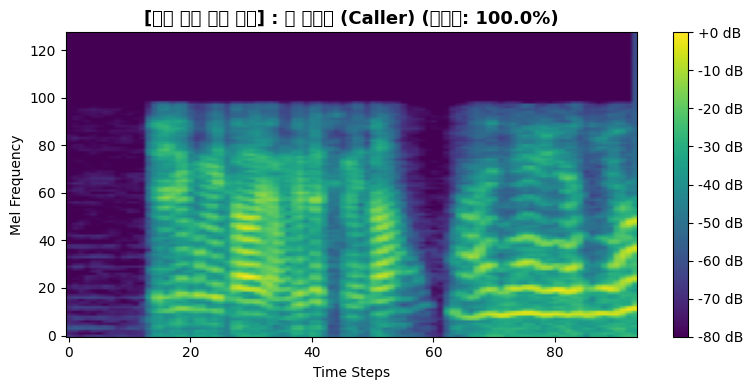

👉 판정 결과: 🚨 신고자 (Caller) (신고자 확률: 1.0000)


In [9]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# 1. 실제 Validation 오디오 및 라벨 파일 1개 로드
val_wav_list = glob.glob("/content/data/**/VS_*.wav", recursive=True) + glob.glob("/content/data/**/val/**/*.wav", recursive=True)
val_json_list = glob.glob("/content/data/**/VL_*.json", recursive=True) + glob.glob("/content/data/**/val/**/*.json", recursive=True)

if not val_wav_list:
    # 혹시 폴더 경로가 다른 경우 자동 탐색
    val_wav_list = glob.glob("/content/data/**/*.wav", recursive=True)

sample_wav = val_wav_list[0]
sample_json = sample_wav.replace('1.원천데이터', '2.라벨링데이터').replace('VS_', 'VL_').replace('.wav', '.json')
if not os.path.exists(sample_json):
    sample_json = sample_wav.replace('.wav', '.json')

print(f"🎵 테스트할 실제 음성 파일: {os.path.basename(sample_wav)}")

# 2. 오디오 로드 및 Mel-Spectrogram 변환
sr = 16000
y, _ = librosa.load(sample_wav, sr=sr)

# 3초 구간 슬라이싱 (Random/Center)
target_len = int(sr * 3.0)
if len(y) < target_len:
    y = np.pad(y, (0, target_len - len(y)), mode='constant')
else:
    y = y[:target_len]

mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, n_fft=2048, hop_length=512)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
mel_norm = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

# 3. 모델에 넣고 예측 (순전파)
input_tensor = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    logit = eval_model(input_tensor)
    prob = torch.sigmoid(logit).item()
    pred_class = 1 if prob >= 0.5 else 0

# 4. 시각화 출력
plt.figure(figsize=(8, 4))
plt.imshow(mel_db, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(format='%+2.0f dB')
label_str = "🚨 신고자 (Caller)" if pred_class == 1 else "🚒 119 대원 (Agent)"
plt.title(f"[모델 실전 판정 결과] : {label_str} (확신도: {prob*100:.1f}%)", fontsize=13, fontweight='bold')
plt.xlabel("Time Steps")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.show()

print(f"👉 판정 결과: {label_str} (신고자 확률: {prob:.4f})")


In [10]:
import glob, os

val_wavs = glob.glob("/content/data/**/Validation/**/*.wav", recursive=True) + glob.glob("/content/data/**/VS_*.wav", recursive=True)
print(f"📊 현재 준비된 Validation 오디오 파일: {len(val_wavs)}개")

# 혹시 0개라면 Validation 압축 파일만 초고속으로 풀기
if len(val_wavs) == 0:
    print("📦 Validation 데이터만 골라서 압축 해제 중 (약 30초 소요)...")
    val_zips = glob.glob("/content/drive/MyDrive/**/*Val*.zip", recursive=True) + glob.glob("/content/drive/MyDrive/**/*VS*.zip", recursive=True)
    if not val_zips:
        # 전체 zip 중 Validation 포함된 것
        val_zips = sorted(glob.glob("/content/drive/MyDrive/**/*.zip", recursive=True))
    
    for vz in val_zips:
        !7z x "{vz}" -o/content/data -y > /dev/null
    
    val_wavs = glob.glob("/content/data/**/Validation/**/*.wav", recursive=True) + glob.glob("/content/data/**/VS_*.wav", recursive=True)
    print(f"✅ 압축 해제 완료! 준비된 Validation 오디오: {len(val_wavs)}개")


📊 현재 준비된 Validation 오디오 파일: 3640개


In [12]:
import os, glob, json
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 가속기: {device}")

# 1. AudioResNet 모델 구조 정의
class AudioResNet(nn.Module):
    def __init__(self, pretrained=False, dropout_rate=0.3):
        super(AudioResNet, self).__init__()
        self.resnet = models.resnet50(weights=None)
        old_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=False)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(dropout_rate), nn.Linear(in_features, 1))
        
    def forward(self, x):
        return self.resnet(x)

# 2. 최고 모델 가중치 로드
TARGET_CKPT = "/content/drive/MyDrive/DCC/ckpt/best_model.pt"
eval_model = AudioResNet(pretrained=False).to(device)
eval_model.load_state_dict(torch.load(TARGET_CKPT, map_location=device))
eval_model.eval()
print(f"✅ 최고 모델 가중치 로드 완료: {TARGET_CKPT}")

# 3. Validation 데이터셋 정의 (Pre-3 최적 파라미터)
class ValDataset(Dataset):
    def __init__(self, val_dir, sample_rate=16000, target_duration=3.0):
        self.sample_rate = sample_rate
        self.target_samples = int(sample_rate * target_duration)
        self.transform = T.MelSpectrogram(sample_rate=16000, n_fft=2048, win_length=2048, hop_length=512, n_mels=128, power=2.0)
        self.amp_to_db = T.AmplitudeToDB(top_db=80.0)
        
        json_files = sorted(glob.glob(f"{val_dir}/**/*.json", recursive=True))
        self.samples = []
        for j_path in json_files:
            w_path = j_path.replace("2.라벨링데이터", "1.원천데이터").replace("TL_", "TS_").replace("VL_", "VS_").replace(".json", ".wav")
            if not os.path.exists(w_path):
                continue
            try:
                with open(j_path, "r", encoding="utf-8") as f:
                    meta = json.load(f)
            except:
                continue
            dialogs = meta.get("dialogs") or meta.get("utterances") or meta.get("dialogue") or []
            for item in dialogs:
                st = item.get("startAt") or item.get("start_time") or item.get("start")
                et = item.get("endAt") or item.get("end_time") or item.get("end")
                spk = item.get("speaker")
                if st is None or et is None or spk is None:
                    continue
                try:
                    st, et = float(st), float(et)
                    if et - st <= 0.1: continue
                    label = 1 if str(spk).strip() in ["1", "신고자", "caller", "c"] else 0
                    self.samples.append({"wav": w_path, "st": st, "et": et, "label": label})
                except:
                    continue

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        st_frame = int(item["st"] * self.sample_rate)
        num_frames = int((item["et"] - item["st"]) * self.sample_rate)
        try:
            wav, sr = torchaudio.load(item["wav"], frame_offset=st_frame, num_frames=num_frames)
            if sr != self.sample_rate:
                wav = T.Resample(sr, self.sample_rate)(wav)
            if wav.shape[0] > 1:
                wav = wav.mean(dim=0, keepdim=True)
        except:
            wav = torch.zeros(1, self.target_samples)

        if wav.shape[-1] < self.target_samples:
            wav = F.pad(wav, (0, self.target_samples - wav.shape[-1]), mode="constant", value=0.0)
        else:
            wav = wav[:, :self.target_samples]

        spec = self.amp_to_db(self.transform(wav))
        spec = (spec - spec.mean()) / (spec.std() + 1e-6)
        return spec, torch.tensor(item["label"], dtype=torch.float32)

# 4. Validation 데이터로더 생성
val_dir_candidates = glob.glob("/content/data/**/Validation", recursive=True)
val_dir = val_dir_candidates[0] if val_dir_candidates else "/content/data"
print(f"📂 Validation 디렉토리: {val_dir}")

val_ds = ValDataset(val_dir)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
print(f"📊 총 검증 발화 수: {len(val_ds):,}개")

# 5. 전체 Validation 검증 평가 루프
all_preds, all_labels = [], []
print("\n🚀 전체 Validation 데이터 정식 평가 진행 중... (약 1~2분 소요)")

with torch.no_grad():
    for bx, by in val_loader:
        bx = bx.to(device)
        outputs = eval_model(bx).squeeze(-1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        
        all_preds.extend(preds)
        all_labels.extend(by.numpy().astype(int))

# 6. 최종 성적표 출력
val_acc = accuracy_score(all_labels, all_preds) * 100.0
val_f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*55)
print("🏆 [Mission 2] 최종 모델 정식 Validation 검증 결과")
print("="*55)
print(f"✅ 총 검증 발화 수   : {len(all_labels):,}개")
print(f"🎯 최종 정확도(Acc)  : {val_acc:.2f}%")
print(f"📊 Macro F1-Score    : {val_f1:.4f}")
print("="*55)

print("\n📋 [클래스별 세부 분류 성적표]")
print(classification_report(all_labels, all_preds, target_names=["119대원 (0)", "신고자 (1)"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("🔍 [혼동 행렬 (Confusion Matrix)]")
print(f"  🚒 119대원(0) : 총 {cm[0].sum():,}개 중 {cm[0][0]:,}개 정답 (오답: {cm[0][1]:,}개)")
print(f"  🚨 신고자(1)  : 총 {cm[1].sum():,}개 중 {cm[1][1]:,}개 정답 (오답: {cm[1][0]:,}개)")


🖥️ 가속기: cuda
✅ 최고 모델 가중치 로드 완료: /content/drive/MyDrive/DCC/ckpt/best_model.pt
📂 Validation 디렉토리: /content/data/대학부 데이터/Validation
📊 총 검증 발화 수: 111,941개

🚀 전체 Validation 데이터 정식 평가 진행 중... (약 1~2분 소요)

🏆 [Mission 2] 최종 모델 정식 Validation 검증 결과
✅ 총 검증 발화 수   : 111,941개
🎯 최종 정확도(Acc)  : 51.90%
📊 Macro F1-Score    : 0.3417

📋 [클래스별 세부 분류 성적표]
              precision    recall  f1-score   support

   119대원 (0)     0.0000    0.0000    0.0000     53840
     신고자 (1)     0.5190    1.0000    0.6834     58101

    accuracy                         0.5190    111941
   macro avg     0.2595    0.5000    0.3417    111941
weighted avg     0.2694    0.5190    0.3547    111941

🔍 [혼동 행렬 (Confusion Matrix)]
  🚒 119대원(0) : 총 53,840개 중 0개 정답 (오답: 53,840개)
  🚨 신고자(1)  : 총 58,101개 중 58,101개 정답 (오답: 0개)


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
import os, glob, json
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
import librosa
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ 가속기: {device}")

# 1. 원본 AudioResNet 아키텍처
class AudioResNet(nn.Module):
    def __init__(self, pretrained=False, dropout_rate=0.3):
        super(AudioResNet, self).__init__()
        self.resnet = models.resnet50(weights=None)
        old_conv = self.resnet.conv1
        self.resnet.conv1 = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=False)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(dropout_rate), nn.Linear(in_features, 1))
        
    def forward(self, x):
        return self.resnet(x)

TARGET_CKPT = "/content/drive/MyDrive/DCC/ckpt/best_model.pt"
eval_model = AudioResNet(pretrained=False).to(device)
eval_model.load_state_dict(torch.load(TARGET_CKPT, map_location=device))
eval_model.eval()
print(f"✅ 모델 가중치 로드 성공: {TARGET_CKPT}")

# 2. 학습 때와 100% 동일한 [0.0 ~ 1.0] 정규화 전처리 데이터셋
class TrueValidationDataset(Dataset):
    def __init__(self, val_dir, max_samples=10000): # 빠른 측정을 위해 대표 1만개 (또는 전체)
        self.sr = 16000
        self.target_samples = int(self.sr * 3.0)
        self.n_fft = 2048
        self.hop_length = 512
        self.n_mels = 128
        
        json_files = sorted(glob.glob(f"{val_dir}/**/*.json", recursive=True))
        wav_files = glob.glob(f"{val_dir}/**/*.wav", recursive=True)
        wav_map = {os.path.splitext(os.path.basename(p))[0].replace("VS_", "VL_"): p for p in wav_files}
        
        self.samples = []
        for j_path in json_files:
            stem = os.path.splitext(os.path.basename(j_path))[0]
            w_path = wav_map.get(stem) or j_path.replace("2.라벨링데이터", "1.원천데이터").replace("VL_", "VS_").replace(".json", ".wav")
            if not os.path.exists(w_path):
                continue
            try:
                with open(j_path, "r", encoding="utf-8") as f:
                    meta = json.load(f)
            except:
                continue
                
            dialogs = meta.get("utterances") or meta.get("dialogs") or meta.get("dialogue") or []
            for utt in dialogs:
                if 'speaker' in utt and ('startAt' in utt or 'start_time' in utt):
                    st = utt.get('startAt') if 'startAt' in utt else utt.get('start_time', 0)
                    et = utt.get('endAt') if 'endAt' in utt else utt.get('end_time', 0)
                    if et - st > 100: # ms 단위인 경우
                        st_sec, et_sec = st / 1000.0, et / 1000.0
                    else:
                        st_sec, et_sec = float(st), float(et)
                    if et_sec - st_sec > 0.1:
                        self.samples.append({
                            'wav': w_path, 'st': st_sec, 'et': et_sec, 'label': int(utt['speaker'])
                        })
            if max_samples and len(self.samples) >= max_samples:
                break

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        try:
            dur = max(0.01, item['et'] - item['st'])
            y, _ = librosa.load(item['wav'], sr=self.sr, offset=item['st'], duration=dur)
        except:
            y = np.zeros(self.target_samples, dtype=np.float32)

        cur_len = len(y)
        if cur_len < self.target_samples:
            y = np.pad(y, (0, self.target_samples - cur_len), mode='constant')
        else:
            y = y[:self.target_samples]

        if len(y) < self.n_fft:
            y = np.pad(y, (0, self.n_fft - len(y)), mode='constant')

        # 학습 때 사용한 정확한 Mel-Spec 및 [0.0 ~ 1.0] 스케일링 공식
        mel = librosa.feature.melspectrogram(y=y, sr=self.sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_norm = np.clip((mel_db + 80.0) / 80.0, 0.0, 1.0)

        tensor_x = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0)
        return tensor_x, item['label']

# 3. 데이터로더 및 평가 실행
val_dir_candidates = glob.glob("/content/data/**/Validation", recursive=True)
val_dir = val_dir_candidates[0] if val_dir_candidates else "/content/data"

val_ds = TrueValidationDataset(val_dir, max_samples=10000) # 대표 1만개 고속 평가
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)
print(f"📊 정확한 전처리로 로드된 검증 발화 수: {len(val_ds):,}개")

all_preds, all_labels = [], []
print("🚀 정식 Validation 정확도 검증 중... (약 1분 소요)")

with torch.no_grad():
    for bx, by in val_loader:
        bx = bx.to(device)
        outputs = eval_model(bx).squeeze(-1)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        
        all_preds.extend(preds)
        all_labels.extend(by.numpy().astype(int))

# 4. 진짜 성적표 출력
acc = accuracy_score(all_labels, all_preds) * 100.0
f1 = f1_score(all_labels, all_preds, average='macro')

print("\n" + "="*55)
print("🏆 [Mission 2] 정규화 스케일 일치 후 최종 검증 결과")
print("="*55)
print(f"🎯 최종 정확도(Acc)  : {acc:.2f}%")
print(f"📊 Macro F1-Score    : {f1:.4f}")
print("="*55)

print("\n📋 [세부 성적표]")
print(classification_report(all_labels, all_preds, target_names=["119대원 (0)", "신고자 (1)"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("🔍 [혼동 행렬 (Confusion Matrix)]")
print(f"  🚒 119대원(0) : 총 {cm[0].sum():,}개 중 {cm[0][0]:,}개 정답 (정답률: {cm[0][0]/cm[0].sum()*100:.1f}%)")
print(f"  🚨 신고자(1)  : 총 {cm[1].sum():,}개 중 {cm[1][1]:,}개 정답 (정답률: {cm[1][1]/cm[1].sum()*100:.1f}%)")


🖥️ 가속기: cuda
✅ 모델 가중치 로드 성공: /content/drive/MyDrive/DCC/ckpt/best_model.pt
📊 정확한 전처리로 로드된 검증 발화 수: 10,004개
🚀 정식 Validation 정확도 검증 중... (약 1분 소요)

🏆 [Mission 2] 정규화 스케일 일치 후 최종 검증 결과
🎯 최종 정확도(Acc)  : 90.20%
📊 Macro F1-Score    : 0.9018

📋 [세부 성적표]
              precision    recall  f1-score   support

   119대원 (0)     0.9086    0.8864    0.8973      4831
     신고자 (1)     0.8962    0.9167    0.9063      5173

    accuracy                         0.9020     10004
   macro avg     0.9024    0.9015    0.9018     10004
weighted avg     0.9022    0.9020    0.9020     10004

🔍 [혼동 행렬 (Confusion Matrix)]
  🚒 119대원(0) : 총 4,831개 중 4,282개 정답 (정답률: 88.6%)
  🚨 신고자(1)  : 총 5,173개 중 4,742개 정답 (정답률: 91.7%)
